# Example code for using pandas for the python 5 (week 10) programming task

The code below doesnt produce the same output. Instead, it will introduce `pandas` and will use dataframe operations to concatenate, by column the data from each data logger file. Remember, each file essentially has four columns: index, date, time, and temperature. We want only date, time, AM/PM, and temperature, and we want the heading for each column to be some representation of the file name. 

We will then use the symmetrical data frame to explore pandas a bit as an alternative tutorial to what we will cover next week in class.

### Import libraries

Here we are using four libraries. What each library does:

- `glob`: Searches for files and directories using patterns (wildcards). For example, glob.glob("*.txt") finds all text files in the current directory. This is extremely useful when you want to loop through many files automatically instead of typing their names one by one.

- `os`:Provides a way to interact with your operating system (for example, renaming files, joining paths, or getting file names from full paths). We’ll use it later to clean file names and extract only the base names for labeling our data.

- `io`: Allows Python to treat text strings as if they were files. This is handy when you’ve read raw text into memory and want to process it as a file-like object using commands such as `pd.read_csv()`.

- `pandas` — A data analysis library that provides the DataFrame object, which makes it easy to read, clean, combine, and analyze tabular data efficiently. If you don’t already have pandas installed, you can install it from the command line:
```sh

pip install pandas # using pip
conda install pandas # if you are using anaconda
```

In [85]:
import glob, os, io
import pandas as pd
%pwd

'/Users/thomasparchman/Documents/GitHub/F25_BIOL792/week11_python_pandas_numpyI/logfiles'

### Defining a function to safely read each tab-delimited file

We haven't seen functions yet in python, so here you go. This chunk of code defines a function that can be called later as `read_logger_file()`, where the filename or path will be fed as an argument in parentheses. This will later be used instead of `open` or `pd.read`.

Many data loggers (and even sequencing or instrument software) export text files that can contain hidden NULL characters (`\x00`) or other odd encodings (e.g., the degree symbol). These can cause `UnicodeDecodeError` or prevent `pandas` or `open` from reading the file correctly. The function below  handles those issues and ensures each file is read cleanly into a pandas DataFrame.

This thing works by:

- Read bytes and strip NULLs (\x00)

- Decode as UTF-8, fall back to Latin-1

- Parse as tab-delimited

- Strip whitespace from column names


In [86]:
def read_logger_file(path):
    """Read a tab-delimited logger file, remove null bytes, and handle encoding safely."""
    with open(path, "rb") as f:
        raw = f.read().replace(b"\x00", b"")  # remove NULLs that break parsing
    try:
        text = raw.decode("utf-8")
    except UnicodeDecodeError:
        text = raw.decode("latin-1")  # fallback for ° symbol or other byte oddities
    # Read as tab-separated, strip whitespace from headers
    df = pd.read_csv(io.StringIO(text), sep="\t")
    df.columns = [c.strip() for c in df.columns]
    return df

### Listing and confirming input files with `glob`

Here we are using `glob` to automatically find all of the logger data files.

The code below looks through the current working directory for all files ending with `.txt.txt`, and then stores the filenames in `filelist`.  `print` statement here is just used to confirm and illustrate that this is working.

In [87]:
filelist = [f for f in glob.glob("*.txt.txt") if not os.path.basename(f).startswith("._")]
print("Found", len(filelist), "files")
print(filelist)

Found 75 files
['1901302120_H5_D_13.txt.txt', '1901302235_H6_S_14.txt.txt', '1901302225_H12_D_13.txt.txt', '1901302121_H8_S_14.txt.txt', '1901302158_H9_S_13.txt.txt', '1901302217_H18_D_14.txt.txt', '1901302236_H17_D_13.txt.txt', '1901302110_H13_S_14.txt.txt', '1901302146_H14_D_14.txt.txt', '1901302222_H2_S_13.txt.txt', '1901302240_H8_D_14.txt.txt', '1901302109_H7_S_14.txt.txt', '1901302212_H9_D_13.txt.txt', '1901302150_H14_S_14.txt.txt', '1901302119_H4_S_13.txt.txt', '1901302141_H19_S_14.txt.txt', '1901302241_H2_D_14.txt.txt', '1901302203_H7_S_13.txt.txt', '1901302118_H1_D_13.txt.txt', '1901302194_H10_S_14.txt.txt', '1901302117_H15_S_13.txt.txt', '1901302227_H11_S_14.txt.txt', '1901302224_H3_S_13.txt.txt', '1901302237_H10_D_13.txt.txt', '1901302136_H15_D_14.txt.txt', '1901302108_H7_D_13.txt.txt', '1901302115_H1_S_13.txt.txt', '1901302138_H11_D_13.txt.txt', '1901302228_H4_D_13.txt.txt', '1901302223_H16_S_14.txt.txt', '1901302134_H13_D_13.txt.txt', '1901302157_H12_S_13.txt.txt', '1901302

### Initializing `blocks` list for use later.

Below we are initializing the list `blocks` so that we can grow it later. Each time the below loop runs, we’ll append a new dataframe (representing one file’s data) to this list before using`pandas` functions such as `pd.concat()` or ``pd.merge()` to combine everything in `blocks` into one structured dataframe.

In [88]:
blocks = []

### Looping through all files and building clean DataFrames

This block builds one temperature column per input file by:

- Read/clean it with function from above to clean gremlins

- Build a timestamp from Date + Time. pd.to_datetime() handles AM/PM automatically.

- Round timestamps to the nearest minute to improve alignment across files.

- Select the temperature column. We use a simple heuristic: pick the first column whose header contains "Read" and "F" (covers variants like Readings (°F), Readings (?F), etc.).

- Create a small DataFrame with index = timestamp and one column named from the file.

In [89]:
blocks = []

for fn in filelist:
    df = read_logger_file(fn)

    # 4.1 Build timestamp column from Date + Time (AM/PM handled automatically)
    date_str = df["Date"].astype(str).str.strip()
    time_str = df["Time"].astype(str).str.strip()
    ts = pd.to_datetime(date_str + " " + time_str, errors="coerce").dt.round("T")

    # 4.2 Select the temperature column (adjust if your headers differ)
    # This “contains” test is forgiving to small header variations and mojibake.
    possible_cols = [c for c in df.columns if "Read" in c and "F" in c]
    if not possible_cols:
        print(f"[WARN] {os.path.basename(fn)}: no temperature-like column found; skipping.")
        continue
    tempF = pd.to_numeric(df[possible_cols[0]], errors="coerce")

    # 4.3 Name the column from the filename (drop .txt.txt)
    stem = os.path.splitext(os.path.splitext(os.path.basename(fn))[0])[0]
    colname = f"{stem}_F"

    # 4.4 Build the per-file one-column DataFrame (index = timestamp)
    block = pd.DataFrame({colname: tempF.values}, index=ts)

    # 4.5 Optional: if the file has multiple rows for the same minute, average them
    block = block.groupby(level=0).mean(numeric_only=True)

    blocks.append(block)


/var/folders/m2/04t_0bnx1rv6940_lc07qdbm0000gn/T/ipykernel_45747/2092162488.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ts = pd.to_datetime(date_str + " " + time_str, errors="coerce").dt.round("T")
/var/folders/m2/04t_0bnx1rv6940_lc07qdbm0000gn/T/ipykernel_45747/2092162488.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ts = pd.to_datetime(date_str + " " + time_str, errors="coerce").dt.round("T")


### Combining all DataFrames into one dataframe

Now that we have one small dataframe per input file stored in our list `blocks`, we can merge them all together into a single large dataframe.  
This is done with the `pandas.concat()` function, which can combine multiple dataframes either **row-wise** (`axis=0`) or **column-wise** (`axis=1`).

Here we use `axis=1` to align the data **by timestamp** and bind the columns side by side — similar to `cbind()` in R.

Since each of the smaller dataframes in `block` share the same timestamp index, `pd.concat()` automatically lines up data from the same date and time across all sensors or files. Where timestamps are missing from some files, pandas will fill those cells with NaN, preserving the time alignment.


The resulting variable merged is now one large, well-structured DataFrame that combines all of the temperature and AM/PM columns from every file in the directory.


In [90]:
merged = pd.concat(blocks, axis=1)
merged.shape

(99199, 75)

### Sorting the merged DataFrame by timestamp

After merging dataframes, it’s good to make sure the rows are in chronological order. The code below checks whether the `pandas` dataframe’s index is actually a datetime object and, if so, sorts it from earliest to latest.

In [91]:
# Sort by time if the index is datetime
if pd.api.types.is_datetime64_any_dtype(merged.index):
    merged = merged.sort_index()
merged.shape

(99199, 75)

#### optional, drop rows that consist of all NaN

In [92]:
merged = merged.dropna(how="all")
merged.shape

(99199, 75)

### Writing the combined dataframe to a .csv file

The final step exports cleaned and merged dataset so it can be easily shared or analyzed later.  
The code below writes the fataframe to a file, making sure that the timestamps are clearly labeled as the first column.



In [93]:
# Give the index a name so the first CSV cell isn't blank
merged.to_csv("cbind_by_timestamp.csv", index_label="timestamp")
print("Wrote cbind_by_timestamp.csv with shape:", merged.shape)
merged.head()

Wrote cbind_by_timestamp.csv with shape: (99199, 75)


,1901302120_H5_D_13_F,1901302235_H6_S_14_F,1901302225_H12_D_13_F,1901302121_H8_S_14_F,1901302158_H9_S_13_F,1901302217_H18_D_14_F,1901302236_H17_D_13_F,1901302110_H13_S_14_F,1901302146_H14_D_14_F,1901302222_H2_S_13_F,...,1901302243_H5_S_13_F,1901302122_H3_D_13_F,1901302137_H18_S_14_F,1901302214_H19_D_14_F,1901302223_H16_S_13_F,1901302134_H13_D_14_F,1901302157_H12_S_14_F,1901302138_H11_D_14_F,1901302228_H4_D_14_F,1901302115_H1_S_14_F
2012-09-30 08:00:00,44.8,NaN,41.4,NaN,NaN,NaN,NaN,NaN,NaN,43.9,...,43.9,51.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-09-30 08:35:00,44.7,NaN,41.6,NaN,NaN,NaN,NaN,NaN,NaN,44.9,...,44.0,51.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-09-30 09:10:00,44.6,NaN,42.0,NaN,NaN,NaN,NaN,NaN,NaN,45.9,...,43.8,51.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-09-30 09:45:00,44.7,NaN,42.3,NaN,NaN,NaN,NaN,NaN,NaN,46.9,...,43.7,51.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-09-30 10:20:00,44.7,NaN,42.7,NaN,NaN,NaN,NaN,NaN,NaN,48.4,...,43.5,51.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data visualization for exploration

### Load data and do some basic checks

- Reads the merged CSV (cbind_by_timestamp.csv) and turns the timestamp column into a real datetime index (so time-based tools like resampling work).

- Sorts rows by time.

- Coerces all columns to numeric so any stray text/units become NaN instead of breaking computations.

- Prints overall shape, date range, and a quick look at missingness by column.


In [117]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load and prep
merged = pd.read_csv("cbind_by_timestamp.csv",
                     index_col="timestamp",
                     parse_dates=["timestamp"]).sort_index()
merged = merged.apply(pd.to_numeric, errors="coerce")

print("Shape (rows, cols):", merged.shape)
print("Time span:", merged.index.min(), "→", merged.index.max())
print("Datetime index?", pd.api.types.is_datetime64_any_dtype(merged.index))

# Quick missingness summary
non_null = merged.count().sort_values(ascending=False)
na_pct = (merged.isna().mean() * 100).round(1).sort_values(ascending=False)
print("\nTop 5 by non-null:\n", non_null.head())
print("\nTop 5 by % missing:\n", na_pct.head())

Shape (rows, cols): (99199, 75)
Time span: 2012-09-30 08:00:00 → 2014-09-06 14:00:00
Datetime index? True

Top 5 by non-null:
 1901302222_H2_S_13_F     15018
1901302227_H11_S_13_F    14947
1901302138_H11_D_13_F    14947
1901302236_H17_D_13_F    14661
1901302109_H7_S_13_F     14661
dtype: int64

Top 5 by % missing:
 1901302203_H7_S_14_F     86.3
1901302212_H9_D_14_F     86.3
1901302227_H11_S_14_F    86.3
1901302158_H9_S_14_F     86.3
1901302202_H16_S_14_F    86.3
dtype: float64


### a function for robust series cleaning + y-limits
    
Takes one column (a single logger) and:

- coerces to numeric,
- drops NaN 
- computes robust y-limits from the 1st–99th percentile (ignoring extreme outliers), with a small padding. This is done because strongly outlier values can make autoscaling flatten timeseries plots.

In [118]:
def robust_series_for_plot(s, q_lo=0.01, q_hi=0.99):
    """Numeric only, drop NaN/±Inf, and return robust y-lims based on quantiles."""
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if s.empty:
        return s, (0.0, 1.0)
    lo, hi = s.quantile([q_lo, q_hi]).values
    pad = max(1.0, 0.05 * (hi - lo))
    return s, (lo - pad, hi + pad)

### Availability heatmap (who has data when?)

- Builds a 0/1 matrix showing whether each logger has data at each time bin.

- Downsamples to hourly bins so the image stays small and interpretable.

- Plots the matrix as a heatmap (1 = has data, 0 = missing).

- The heatmap is a diagnostic for missing sensors, outages, or non-overlapping recording periods.

- good example of boolean presence ~isna(), resampling to coarser time (.resample("1H").max()), matrix visualization.

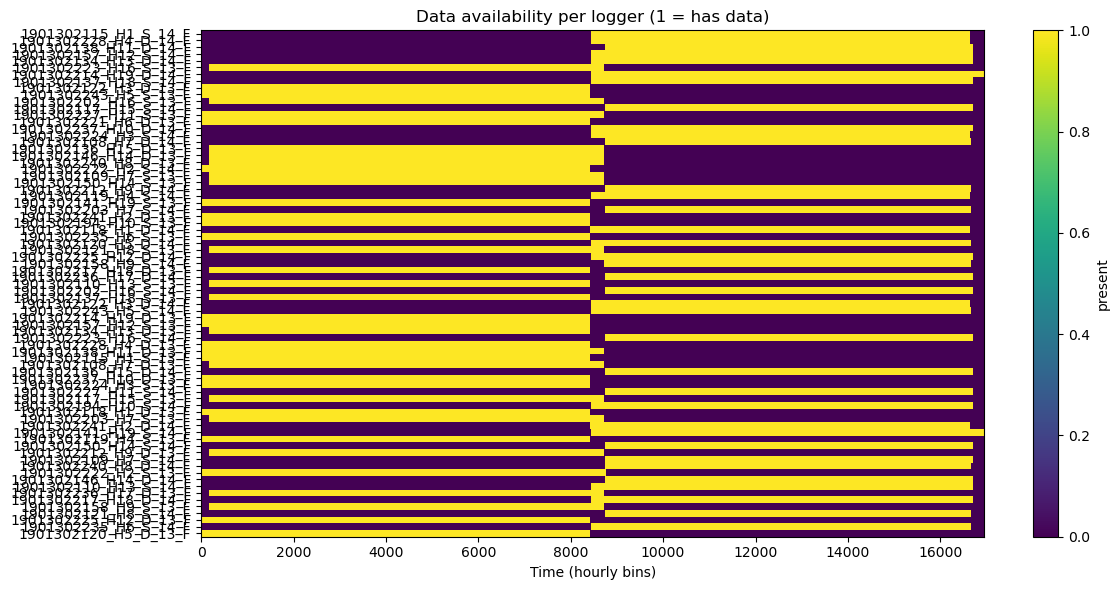

In [119]:
Fcols = [c for c in merged.columns if c.endswith("_F")]
present = (~merged[Fcols].isna()).astype(int)
present_h = present.resample("1H").max()

plt.figure(figsize=(12, 6))
plt.imshow(present_h.T, aspect="auto", interpolation="nearest", origin="lower")
plt.yticks(range(len(Fcols)), Fcols)
plt.xlabel("Time (hourly bins)")
plt.title("Data availability per logger (1 = has data)")
cbar = plt.colorbar()
cbar.set_label("present")
plt.tight_layout()
plt.show()

### Plot one target series from one file to check

- Picks a single column (the “target”) and cleans it with the helper in step 2.

- Plots both line and scatter on top of each other.

- Uses robust y-limits so outliers can’t squash the signal.

When students say “the plot is blank,” it’s usually y-axis scaling, infinities, or extreme values. This pattern avoids those pitfalls.

Line + scatter helps visualize both the trend and the density/sparsity of points.

1901302235_H6_S_14_F: non-null total=14081, finite=14081


<Figure size 640x480 with 0 Axes>

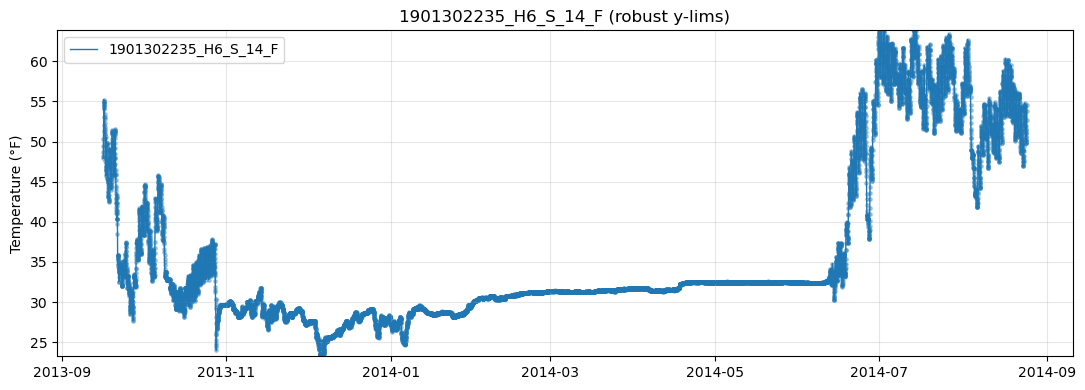

In [130]:
target = "1901302235_H6_S_14_F"  # change to any column name you want
#target = "1901302243_H5_S_14_F"

if target in merged.columns:
    s, (ymin, ymax) = robust_series_for_plot(merged[target])
    print(f"{target}: non-null total={merged[target].notna().sum()}, finite={len(s)}")

    plt.clf()
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(s.index.values, s.values, linewidth=1, label=target)
    ax.scatter(s.index.values, s.values, s=6, alpha=0.35)
    ax.set_title(f"{target} (robust y-lims)")
    ax.set_ylabel("Temperature (°F)")
    ax.set_ylim(ymin, ymax)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("Target not found:", target)
#plt.savefig("singletarget_timeseries.pdf", bbox_inches="tight") #for writing to pdf

### Compare many series at once (z-scored overlay)

- Selects the K most complete loggers (e.g., top 20 by non-missing count).

- Creates a common time grid (e.g., every 30 minutes) and resamples each series to that grid.

- Standardizes each series to z-scores: subtract its mean and divide by its standard deviation.

- Overlays all standardized series on one plot.

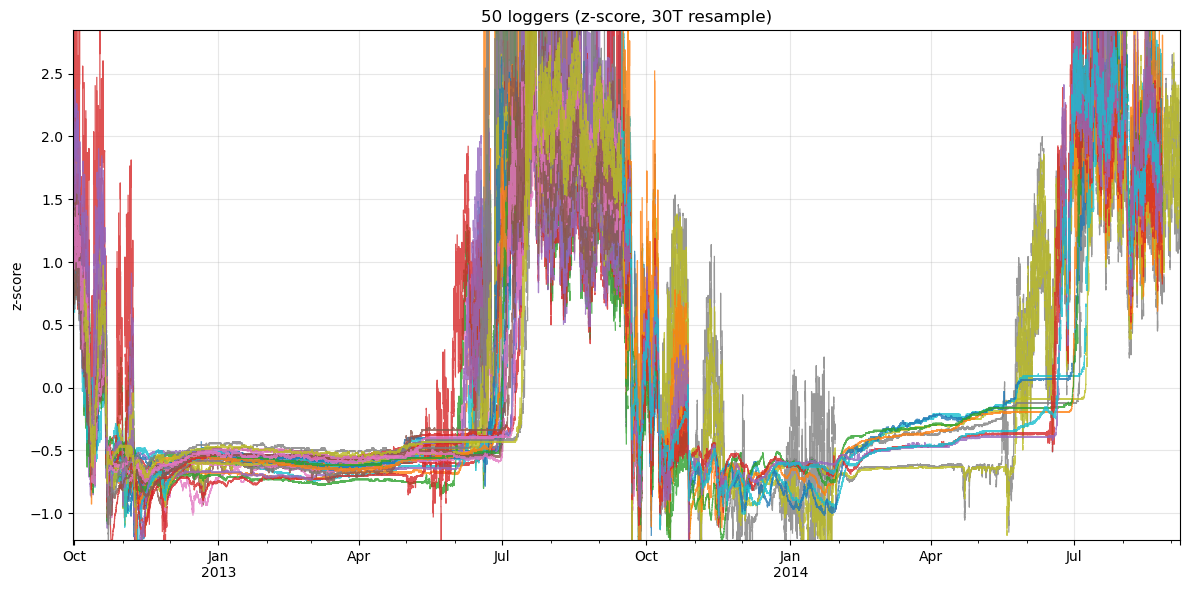

In [133]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

K = 50
non_null = merged.count().sort_values(ascending=False)
cols = non_null.index[:K]
FREQ = "30T"  # coarser grid helps readability with many series

tmin = min(merged[c].dropna().index.min() for c in cols if merged[c].notna().any())
tmax = max(merged[c].dropna().index.max() for c in cols if merged[c].notna().any())
grid = pd.date_range(tmin, tmax, freq=FREQ)

normd = {}
for c in cols:
    s = pd.to_numeric(merged[c], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if s.empty:
        continue
    s = s.resample(FREQ).mean().reindex(grid)
    mu, sd = s.mean(skipna=True), s.std(skipna=True)
    if pd.notna(sd) and sd > 0:
        normd[c] = (s - mu) / sd

norm_overlay = pd.DataFrame(normd, index=grid)

# y-lims from quantiles of the plotted values
vals = norm_overlay.to_numpy().astype(float)
vals = vals[np.isfinite(vals)]
if vals.size:
    lo, hi = np.quantile(vals, [0.01, 0.99])
    pad = 0.25
    y0, y1 = lo - pad, hi + pad
else:
    y0, y1 = -1, 1

fig, ax = plt.subplots(figsize=(12, 6))
norm_overlay.plot(ax=ax, linewidth=0.9, alpha=0.8, legend=False,
                  title=f"{norm_overlay.shape[1]} loggers (z-score, {FREQ} resample)")
ax.set_ylabel("z-score")
ax.set_ylim(y0, y1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#plt.savefig("zscore_timeseries_many.pdf", bbox_inches="tight") #for writing to pdf

### Small-multiple panels (facets) of the top N series

- Takes the first N most-complete series (e.g., 8).

- Plots each as its own mini time series (one per subplot) with robust y-limits.



In [135]:
top_cols = non_null.index[:75]
rows = len(top_cols)

plt.figure(figsize=(12, 2 * rows))
for i, c in enumerate(top_cols, start=1):
    s_i, (yl0, yl1) = robust_series_for_plot(merged[c])
    ax = plt.subplot(rows, 1, i)
    if not s_i.empty:
        ax.plot(s_i.index.values, s_i.values, linewidth=1)
        ax.scatter(s_i.index.values, s_i.values, s=4, alpha=0.25)
        ax.set_ylim(yl0, yl1)
    ax.set_title(c, fontsize=9)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#plt.savefig("multipanel_temperature_plots.pdf", bbox_inches="tight") #for writing to pdf

### Per-logger summary stats (for plotting)

In [136]:
import numpy as np
import pandas as pd

# Pick temperature columns
Fcols = [c for c in merged.columns if c.endswith("_F")]

# Basic per-logger summaries (ignoring NaN/±Inf)
def fin(s):
    return pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)

summ = pd.DataFrame({
    "mean":   [fin(merged[c]).mean() for c in Fcols],
    "median": [fin(merged[c]).median() for c in Fcols],
    "std":    [fin(merged[c]).std() for c in Fcols],
    "min":    [fin(merged[c]).min() for c in Fcols],
    "max":    [fin(merged[c]).max() for c in Fcols],
    "nn":     [fin(merged[c]).notna().sum() for c in Fcols],
}, index=Fcols).sort_values("mean")
summ.head()

,mean,median,std,min,max,nn
1901302134_H13_D_14_F,31.986972,30.5,5.570058,24.0,50.0,14162
1901302110_H13_S_14_F,32.240032,30.0,8.021389,22.8,60.9,14161
1901302108_H7_D_14_F,32.706577,30.9,6.337873,24.9,52.2,13547
1901302203_H7_S_14_F,32.955577,30.4,9.426713,21.8,63.0,13547
1901302137_H18_S_14_F,33.210540,30.8,7.705508,20.3,62.1,14165


### Histogram of per-logger mean temperatures

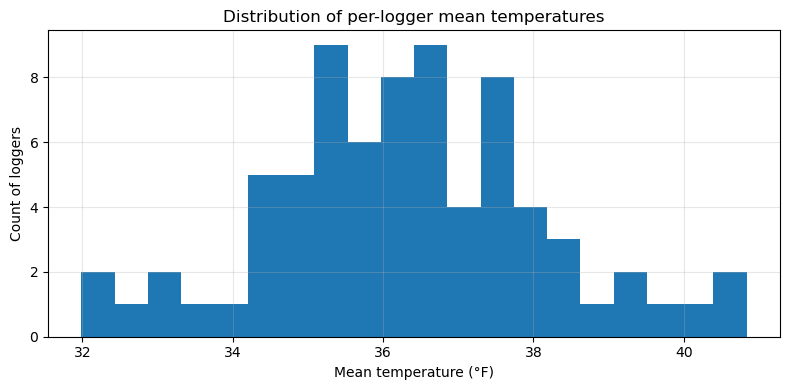

In [137]:
import matplotlib.pyplot as plt
vals = summ["mean"].dropna().to_numpy()

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(vals, bins=20)
ax.set_title("Distribution of per-logger mean temperatures")
ax.set_xlabel("Mean temperature (°F)")
ax.set_ylabel("Count of loggers")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Boxplot of selected loggers (e.g., top 12 by data completeness)

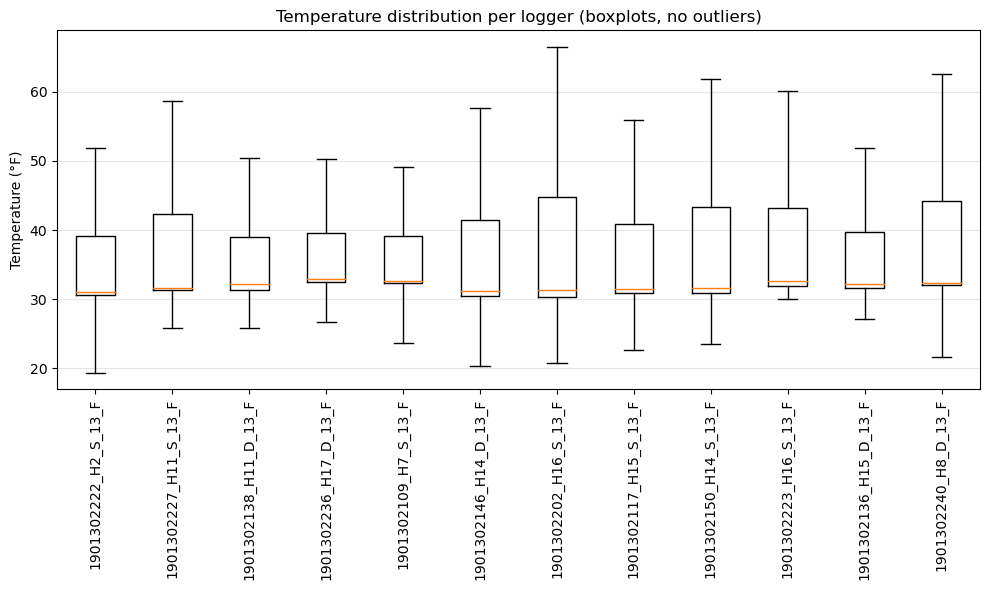

In [138]:
# Choose 12 loggers with most data
top12 = merged[Fcols].count().sort_values(ascending=False).index[:12]

# Build list of numeric series (same length not required)
series_list = [pd.to_numeric(merged[c], errors="coerce").replace([np.inf,-np.inf], np.nan).dropna()
               for c in top12]

fig, ax = plt.subplots(figsize=(10,6))
ax.boxplot(series_list, vert=True, labels=top12, showfliers=False)
ax.set_title("Temperature distribution per logger (boxplots, no outliers)")
ax.set_ylabel("Temperature (°F)")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Violin plot of the same loggers (shape of distribution)

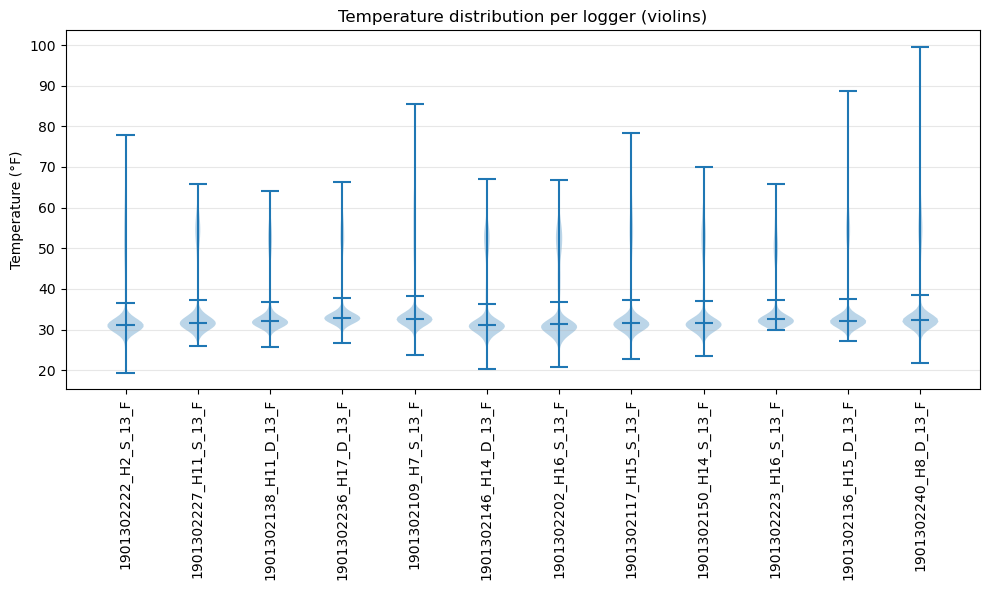

In [139]:
fig, ax = plt.subplots(figsize=(10,6))
ax.violinplot(series_list, showmeans=True, showextrema=True, showmedians=True)
ax.set_title("Temperature distribution per logger (violins)")
ax.set_ylabel("Temperature (°F)")
ax.set_xticks(range(1, len(top12)+1))
ax.set_xticklabels(top12, rotation=90)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Empirical CDF (ECDF) of per-logger means

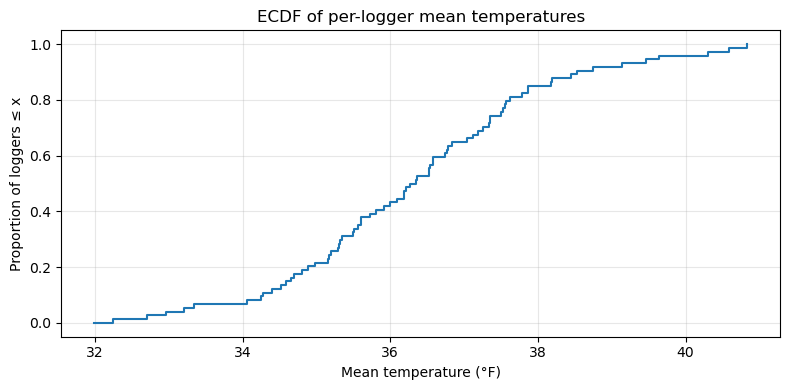

In [140]:
means = summ["mean"].dropna().sort_values().to_numpy()
y = np.linspace(0, 1, len(means), endpoint=True)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(means, y, drawstyle="steps-post")
ax.set_title("ECDF of per-logger mean temperatures")
ax.set_xlabel("Mean temperature (°F)")
ax.set_ylabel("Proportion of loggers ≤ x")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Correlation heatmap (patterns across loggers)

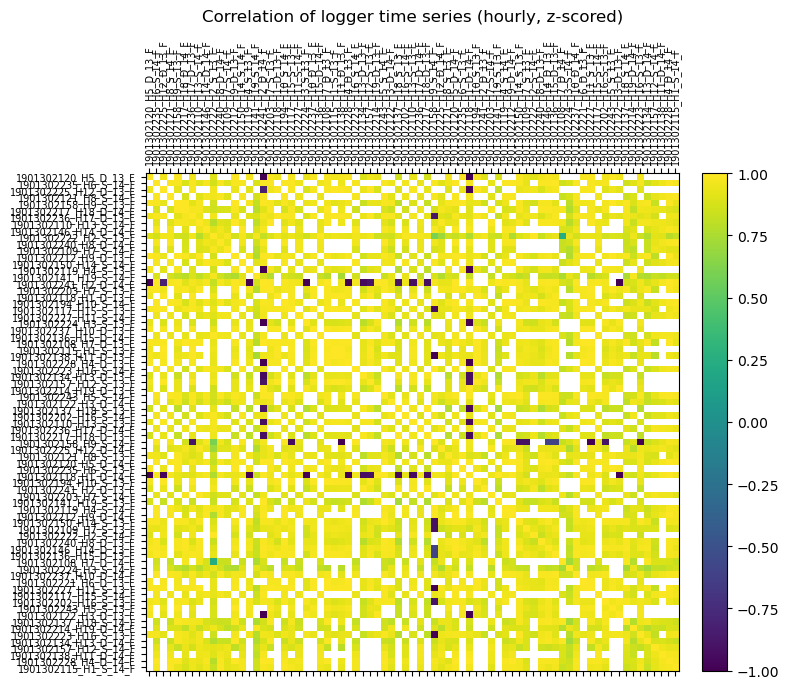

In [142]:
# Downsample to hourly means to align on a common grid
hourly = merged[Fcols].apply(pd.to_numeric, errors="coerce").replace([np.inf,-np.inf], np.nan)
hourly = hourly.resample("1H").mean()

# Z-score each logger (by column) so correlation focuses on shared patterns
z = (hourly - hourly.mean()) / hourly.std()

corr = z.corr()

fig, ax = plt.subplots(figsize=(8,7))
cax = ax.matshow(corr.values, aspect="auto")
ax.set_title("Correlation of logger time series (hourly, z-scored)", pad=12)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.index, fontsize=7)
fig.colorbar(cax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


### Ridgeline-style density sketch (quick + simple)

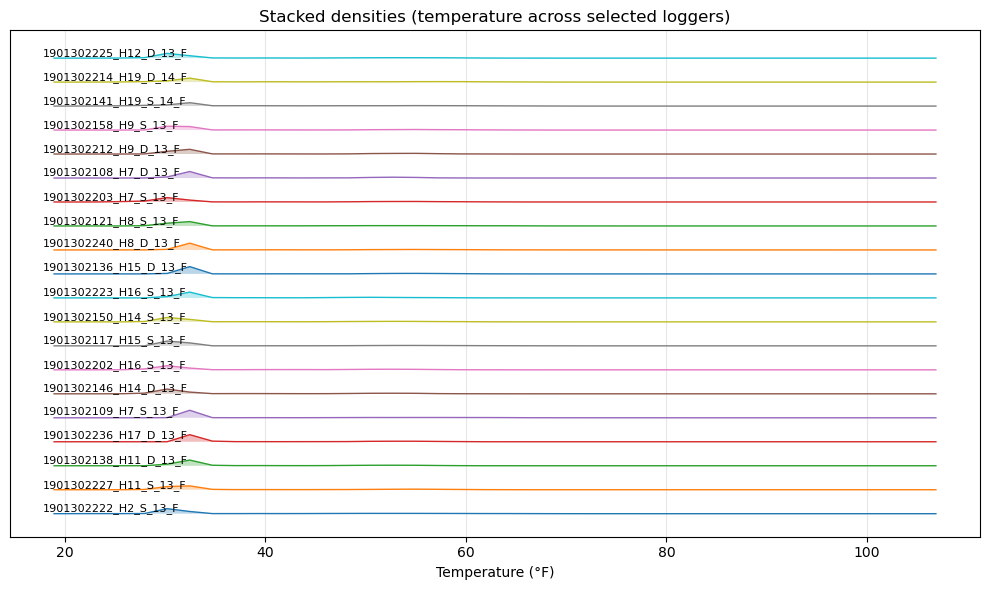

In [145]:
# Kernel-density-ish via normalized histograms, stacked
import numpy as np

sel = merged[Fcols].count().sort_values(ascending=False).index[:20]
xgrid = np.linspace(summ["min"].min(), summ["max"].max(), 200)

fig, ax = plt.subplots(figsize=(10,6))
offset = 0.0
step = 1.0
for c in sel:
    s = pd.to_numeric(merged[c], errors="coerce").replace([np.inf,-np.inf], np.nan).dropna()
    if s.empty:
        continue
    hist, edges = np.histogram(s, bins=40, range=(xgrid.min(), xgrid.max()), density=True)
    centers = 0.5*(edges[1:]+edges[:-1])
    ax.plot(centers, hist + offset, linewidth=1)
    ax.fill_between(centers, offset, hist + offset, alpha=0.3)
    ax.text(xgrid.min(), offset + hist.max()*0.5, c, fontsize=8)
    offset += step

ax.set_title("Stacked densities (temperature across selected loggers)")
ax.set_xlabel("Temperature (°F)")
ax.set_yticks([])
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


### PDF export (one-liner)

In [ ]:
plt.savefig("figure_name.pdf", bbox_inches="tight")
